# Import Libraries

In [1]:
import numpy as np
import pandas as pd

In [2]:
import mlflow
import mlflow.keras
from mlflow import MlflowClient
import bentoml

In [3]:
import sys
import os
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

In [4]:
from features.mfcc_feature_extraction import mfcc_feature_extraction
from utils.visualisation import augmented_lables_count, plot_loss_curves, confusion_matrix_classes
from features.class_labels_encoding import encode_labels_to_categorical
from models.prepare_train_test_data import prepare_test_train_data
from models.model_design_and_training import create_model, train_model
from sklearn.metrics import classification_report, accuracy_score, log_loss

# Mlflow Initiation

In [5]:
TRACKING_URI = "http://127.0.0.1:5000/"
EXPERIMENT_NAME = "deeprespnet-experis"
MODEL_NAME = "DeepRespNet"
# RUN_ID = "101"
# EXPERIMENT_ID = "202"

In [6]:
# Set up MLflow
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

2025/07/21 18:57:35 INFO mlflow.tracking.fluent: Experiment with name 'deeprespnet-experis' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/284481551311861389', creation_time=1753104455301, experiment_id='284481551311861389', last_update_time=1753104455301, lifecycle_stage='active', name='deeprespnet-experis', tags={}>

In [7]:
# Start MLflow run that will persist across cells
run = mlflow.start_run(run_name=MODEL_NAME,description='Was experimenting with mlflow')
print(f"Started MLflow run: {run.info.run_id}")

Started MLflow run: 95c895e7ac8e447f95fdf35e3fa27c24


# Load Dataset

In [8]:
# Location of Data Folder:
data_folder = '../../data/Respiratory_Sound_Data'

In [9]:
# Lung Audio Data Folder:
audio_data_folder = f'{data_folder}/audio_and_txt_files/'

In [10]:
# Test Audio Files:
audio1 = f'{audio_data_folder}104_1b1_Lr_sc_Litt3200.wav'
audio2 = f'{audio_data_folder}224_1b1_Tc_sc_Meditron.wav'
audio3 = f'{audio_data_folder}108_1b1_Al_sc_Meditron.wav'
audio4 = f'{audio_data_folder}182_1b1_Tc_sc_Meditron.wav'
audio5 = f'{audio_data_folder}223_1b1_Al_sc_Meditron.wav'
audio6 = f'{audio_data_folder}226_1b1_Pl_sc_LittC2SE.wav'


In [11]:
diagnosis_df = pd.read_csv('../../notebooks/patient_diagnosis_relabelled.csv')

In [12]:
diagnosis_df

,pid,diagnosis
0,101,Acute
1,102,Healthy
2,103,Chronic
3,104,Chronic
4,105,Acute
...,...,...
121,222,Chronic
122,223,Chronic
123,224,Healthy
124,225,Healthy


# Data Preprocessing

In [13]:
x_mfccs, y = mfcc_feature_extraction(dir_=audio_data_folder,diagnosis_df=diagnosis_df)

Processing 920 audio files...
Processed 50/920 files...
Processed 100/920 files...
Processed 150/920 files...
Processed 200/920 files...
Processed 250/920 files...
Processed 300/920 files...
Processed 350/920 files...
Processed 400/920 files...
Processed 450/920 files...
Processed 500/920 files...
Processed 550/920 files...
Processed 600/920 files...
Processed 650/920 files...
Processed 700/920 files...
Processed 750/920 files...
Processed 800/920 files...
Processed 850/920 files...
Processed 900/920 files...

Feature extraction completed!
Final dataset shape: (997, 52)
Label distribution: {np.str_('Acute'): np.int64(450), np.str_('Chronic'): np.int64(337), np.str_('Healthy'): np.int64(210)}


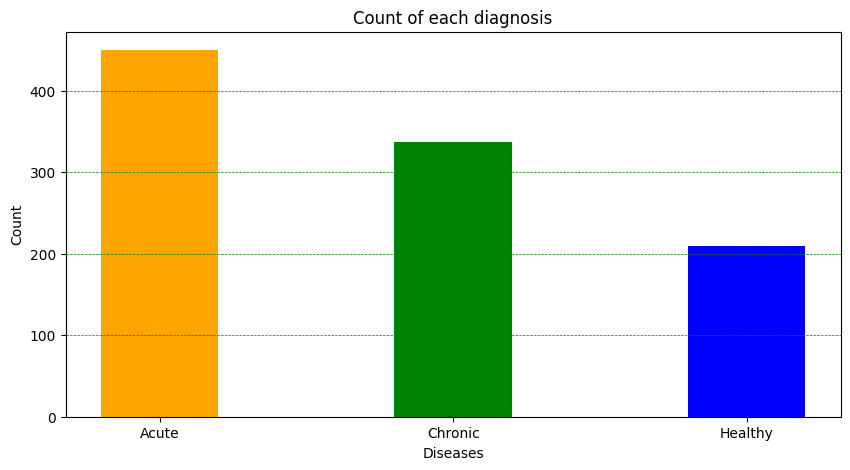

{np.str_('Acute'): np.int64(450), np.str_('Chronic'): np.int64(337), np.str_('Healthy'): np.int64(210)}


In [14]:
augmented_lables_count(y)

In [15]:
Y_data = encode_labels_to_categorical(y=y)

In [16]:
mfccs_features = np.array(x_mfccs)
lables = np.array(Y_data)

mfccs_features.shape , lables.shape

((997, 52), (997, 3))

In [17]:
# Print feature extraction parameters
print(f"total_samples =  {len(mfccs_features)}")
print(f"feature_shape =  {str(mfccs_features.shape[1:])}")
print(f"num_classes =  {Y_data.shape[1]}")
# Log feature extraction parameters
mlflow.log_param("total_samples", len(mfccs_features))
mlflow.log_param("feature_shape", str(mfccs_features.shape[1:]))
mlflow.log_param("num_classes", Y_data.shape[1])

print(f"Feature extraction completed: {mfccs_features.shape}")

total_samples =  997
feature_shape =  (52,)
num_classes =  3
Feature extraction completed: (997, 52)


In [18]:
# Assume mfccs_features and labels are already defined

(x_train, y_train), (x_val, y_val), (x_test, y_test) = prepare_test_train_data(mfccs_features, lables)

print("Training shapes:", x_train.shape, y_train.shape)
print("Validation shapes:", x_val.shape, y_val.shape)
print("Test shapes:", x_test.shape, y_test.shape)

# Log data split information
mlflow.log_param("train_samples", len(x_train))
mlflow.log_param("val_samples", len(x_val))
mlflow.log_param("test_samples", len(x_test))
mlflow.log_param("train_val_test_ratio", f"{len(x_train)}:{len(x_val)}:{len(x_test)}")

Training shapes: (697, 1, 52) (697, 1, 3)
Validation shapes: (200, 1, 52) (200, 1, 3)
Test shapes: (100, 1, 52) (100, 1, 3)


'697:200:100'

# Model Development and Training

## Model Design

In [19]:
deeprespnet_model = create_model()

In [20]:
OPTIMIZER = 'adam'
LOSS_FUNCTION = 'categorical_crossentropy'

deeprespnet_model.compile(
    optimizer=OPTIMIZER,
    loss=LOSS_FUNCTION,
    metrics=['accuracy']
)
# Log hyperparameters
mlflow.log_param("optimizer", OPTIMIZER)
mlflow.log_param("loss_function", LOSS_FUNCTION)

'categorical_crossentropy'

In [21]:
deeprespnet_model.summary()

# Log model architecture info
mlflow.log_param("total_params", deeprespnet_model.count_params())
mlflow.log_param("trainable_params", deeprespnet_model.count_params())

print(f"Model created with {deeprespnet_model.count_params()} parameters")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 52)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1, 256)    │     66,816 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1, 256)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1, 256)    │      1,024 │ max_pooling1d[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1, 512)    │    655,872 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 1, 512)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 512)    │      2,048 │ max_pooling1d_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 1, 64)     │    110,976 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 1, 32)     │     52,416 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 1, 64)     │    110,976 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 1, 128)    │     74,496 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 1, 128)    │     62,208 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_5 (GRU)         │ (None, 1, 128)    │     74,496 │ gru_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 128)    │          0 │ gru_3[0][0],      │
│                     │                   │            │ gru_1[0][0],      │
│                     │                   │            │ gru_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_6 (GRU)         │ (None, 1, 128)    │     99,072 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_8 (GRU)         │ (None, 1, 64)     │     37,248 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_7 (GRU)         │ (None, 1, 32)     │     15,552 │ gru_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_9 (GRU)         │ (None, 1, 32)     │      9,408 │ gru_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 32)     │          0 │ gru_7[0][0],      │
│                     │                   │            │ gru_9[0][0],      │
│                     │                   │            │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 32)     │      1,056 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,398,755 (5.34 MB)

 Trainable params: 1,397,219 (5.33 MB)

 Non-trainable params: 1,536 (6.00 KB)

Model created with 1398755 parameters


## Train Model

In [22]:
# Define hyperparameters
EPOCHS = 5
BATCH_SIZE = 32
history = train_model(deeprespnet_model,x_train,y_train,x_val,y_val,epoch=5,batch_size=32)
# Log hyperparameters
mlflow.log_param("epochs", EPOCHS)
mlflow.log_param("batch_size", BATCH_SIZE)

Epoch 1/5
20/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5566 - loss: 1.0339
Epoch 1: val_accuracy improved from -inf to 0.45000, saving model to ./models/saved_model.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.5663 - loss: 1.0261 - val_accuracy: 0.4500 - val_loss: 1.0494
Epoch 2/5
20/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7069 - loss: 0.8179
Epoch 2: val_accuracy did not improve from 0.45000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7060 - loss: 0.8144 - val_accuracy: 0.4500 - val_loss: 1.0477
Epoch 3/5
20/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7026 - loss: 0.6834
Epoch 3: val_accuracy improved from 0.45000 to 0.50500, saving model to ./models/saved_model.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7060 - loss: 0.6794 - val_accuracy: 0.5050 - val_loss: 0.9905
Epoch 4/5
19/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7738 - loss: 0.5843
Epoch 4: val_accuracy improved from 0.50500 to 0.59500, saving model t

32

In [23]:
# Log training history metrics
for epoch in range(len(history.history['loss'])):
    mlflow.log_metric("train_loss", history.history['loss'][epoch], step=epoch)
    mlflow.log_metric("train_accuracy", history.history['accuracy'][epoch], step=epoch)
    mlflow.log_metric("val_loss", history.history['val_loss'][epoch], step=epoch)
    mlflow.log_metric("val_accuracy", history.history['val_accuracy'][epoch], step=epoch)

print("Training completed!")

Training completed!


## Model Evaluation

In [24]:
train_loss, train_accuracy = deeprespnet_model.evaluate(x_train, y_train, verbose=0)
print(f"Train Accuracy: {train_accuracy} \nTrain Loss: {train_loss}")

Train Accuracy: 0.6169297099113464 
Train Loss: 0.8286427855491638


In [25]:
val_loss, val_accuracy = deeprespnet_model.evaluate(x_val, y_val,verbose=0)
print(f"Validation Accuracy: {val_accuracy} \nValidation Loss: {val_loss}")

Validation Accuracy: 0.5950000286102295 
Validation Loss: 0.8662174344062805


In [26]:
test_loss, test_accuracy = deeprespnet_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy} | Test Loss: {test_loss}")

Test Accuracy: 0.6200000047683716 | Test Loss: 0.822859525680542


In [27]:
# Log final evaluation metrics
mlflow.log_metric("final_train_accuracy", train_accuracy)
mlflow.log_metric("final_train_loss", train_loss)
mlflow.log_metric("final_val_accuracy", val_accuracy) 
mlflow.log_metric("final_val_loss", val_loss)
mlflow.log_metric("final_test_accuracy", test_accuracy)
mlflow.log_metric("final_test_loss", test_loss)

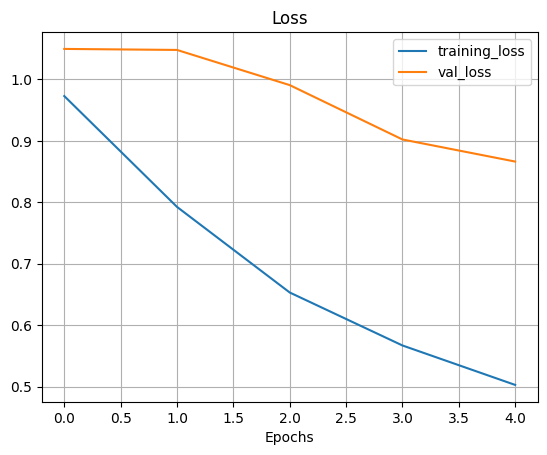

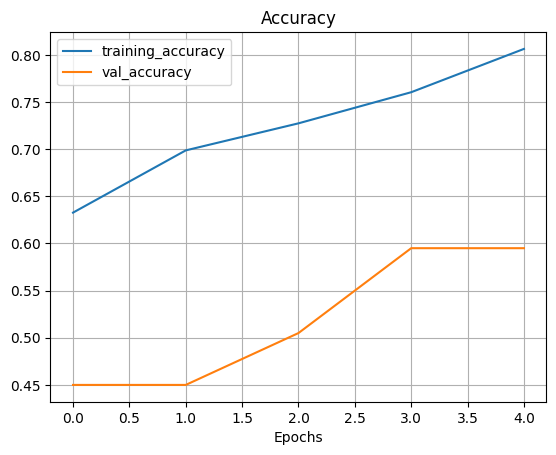

In [28]:
plot_loss_curves(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step


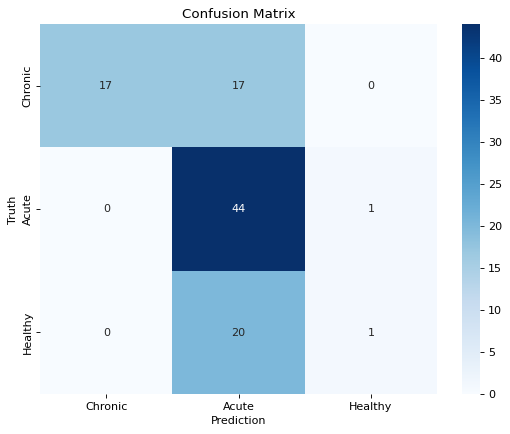

In [29]:
y_testclass, classpreds = confusion_matrix_classes(deeprespnet_model,x_test,y_test)

In [30]:
print(classification_report(y_testclass, classpreds, target_names=['Chronic', 'Acute', 'Healthy']))

              precision    recall  f1-score   support

     Chronic       1.00      0.50      0.67        34
       Acute       0.54      0.98      0.70        45
     Healthy       0.50      0.05      0.09        21

    accuracy                           0.62       100
   macro avg       0.68      0.51      0.48       100
weighted avg       0.69      0.62      0.56       100



In [31]:
class_report = classification_report(y_testclass, classpreds, target_names=['Chronic', 'Acute', 'Healthy'],output_dict=True)
# Log per-class metrics
for class_name in ['Chronic', 'Acute', 'Healthy']:
    if class_name in class_report:
        mlflow.log_metric(f"{class_name}_precision", class_report[class_name]['precision'])
        mlflow.log_metric(f"{class_name}_recall", class_report[class_name]['recall'])
        mlflow.log_metric(f"{class_name}_f1", class_report[class_name]['f1-score'])

# Log macro averages
mlflow.log_metric("macro_avg_precision", class_report['macro avg']['precision'])
mlflow.log_metric("macro_avg_recall", class_report['macro avg']['recall'])
mlflow.log_metric("macro_avg_f1", class_report['macro avg']['f1-score'])

In [32]:
# result1 = deeprespnet_model.evaluate(x_train, y_train)
# result2 = deeprespnet_model.evaluate(x_test, y_test)

In [33]:
# type(result)

# Saving the model

## using Mlflow

In [34]:
# Log model to MLflow
mlflow.keras.log_model( # type: ignore
    deeprespnet_model,
    name="model",
    registered_model_name=MODEL_NAME,
)

print("Model logged to MLflow")

2025/07/21 19:00:10 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/07/21 19:00:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/07/21 19:00:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'DeepRespNet'.
2025/07/21 19:00:17 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DeepRespNet, version 1


Model logged to MLflow


Created version '1' of model 'DeepRespNet'.


## using BentoML

#### Use This if using Mlflow and saving the current model to the mlflow artifact registry then loading it into bentoml's model registory. 

In [35]:
# run = mlflow.active_run()
# run_id = run.info.run_id
# # Construct the model URI
# model_uri = f"{run.info}"
# print(f"Model logged to MLflow with URI: {model_uri}")

In [37]:
client = MlflowClient()
# Very Important
# "mlflow-artifacts:/<experiment-id>/models/<model-id>/artifacts/"
model_uri = client.get_model_version_download_uri(name=MODEL_NAME,version="1")

In [ ]:
# # Check artifacts
# artifacts = client.list_artifacts("3670149f85ed4373a3f5c066db1b80df", "model")
# print(artifacts)
# for artifact in artifacts:
#     print(f"Found: {artifact.path}")
#     if(artifact.path == 'model/MLmodel'):
#         # I want to get the contents of that file
#         pass

In [38]:
save = bool(input("do you want to save it? Enter 0/1"))
if(save):
    bentoml.mlflow.import_model("peepseek",model_uri)

/Users/khubaib/Downloads/DeepRespNet/.venv/lib/python3.12/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/khubaib/Downloads/DeepRespNet/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# # Load the model
# import tensorflow as tf
# deeprespnet_model = tf.keras.models.load_model('./models/ml_flow_model_test.keras')

# # Verify the model loaded correctly
# print("Model loaded successfully!")
# print(f"Model input shape: {deeprespnet_model.input_shape}")
# print(f"Model output shape: {deeprespnet_model.output_shape}")


Model loaded successfully!
Model input shape: (None, 1, 52)
Model output shape: (None, 1, 3)


#### Use This if not using Mlflow and saving the current model directly to the bentoml model's registory. 

In [ ]:
# # **** Save the model to BentoML model store ****


# saved_model = bentoml.keras.save_model(
#     name="lung_sound_classifier",  # This will be the model name/tag
#     model=deeprespnet_model,  # Use the correct variable name
#     metadata={
#         "epochs": "5",
#         "model_type": "CNN-GRU",
#         "input_shape": "(1, 52)",
#         "classes": ["Acute", "Chronic", "Healthy"],
#         "train_accuracy": f"{train_accuracy:.4f}",
#         "val_accuracy": f"{val_accuracy:.4f}",
#         "framework": "tensorflow-keras"
#     },
#     labels={
#         "team": "ml",
#         "stage": "development",
#         "task": "audio_classification"
#     }
# )

# print(f"Model saved successfully: {saved_model.tag}")
# print(f"Model path: {saved_model.path}")

Model saved successfully: deep-seek-ra:piwmtstggcmxmq4i
Model path: /Users/khubaib/bentoml/models/deep-seek-ra/piwmtstggcmxmq4i/


In [ ]:
# deeprespnet_model.save("./diagnosis_model8.h5")

In [ ]:
# deeprespnet_model.save("../models/deeprespnet_model.keras")

In [ ]:
# from keras.models import load_model
# # Step 2: Load it back (as required by BentoML)
# loaded_model = load_model("../models/deeprespnet_model.keras", compile=False)

In [ ]:
# bentoml.keras.save_model(
#         "lung_sound_classifier",
#         loaded_model,
#          metadata={
#             "epochs": "5",
#             "model_type": "CNN-GRU",
#             "input_shape": "(1, 52)",
#             "classes": ["Acute", "Chronic", "Healthy"],
#             "accuracy": "0.70"
#         }
# )

In [ ]:
# history_path = "./models/training_history.npy"
# np.save(history_path, history.history)
# print(f"📊 Training history saved to: {history_path}")

# Prediction

In [ ]:
from predictions import audio_preprocessing, deeprespnet_diagnosis_prediction

classes = ['Chronic','Acute','Healthy']
features = audio_preprocessing(audio_input=audio1)
predicted_class, confidence = deeprespnet_diagnosis_prediction(features=features,model=deeprespnet_model,use_bento_model=False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [ ]:
print(f"Class : {predicted_class}, Confidence : {confidence}")

Class : Acute, Confidence : 0.36050936579704285


# End the MLflow run

In [ ]:
print("View My experiments at: http://localhost:5000")
print("To start MLflow UI, run: mlflow ui")

View My experiments at: http://localhost:5000
To start MLflow UI, run: mlflow ui


In [ ]:
# mlflow.end_run()
# print("MLflow run ended successfully!")